## Simulated Annealing

Simulated annealing is a technique for minimizing functions that makes use of the ideas from Markov chain Monte Carlo samplers, which is why it is in this section of the book. It is a particularly useful method for functions that are very misbehaved and wiggly; the kinds of functions that Newton-style optimizers tend to be bad at minimizing.

Suppose we want to find the global minimum of a function $h(\theta)$, where $\theta$ is a vector of parameters in a space $S$. Ideally, we would simulate a Markov chain whose target density $\pi(\theta)$ was a point mass on the global minimum. This would be great if we could do it! But then we wouldn't have a problem. The idea with simulated annealing is that we build successive approximations to $\pi(\theta)$ until we have an approximation that is very close to the target density.

Let 

$$
S^\star = \{\theta\in S: h(\theta) = \min_\theta h(\theta)\}
$$

. Then define $\pi(\theta)\propto 1$ for all $\theta\in S^\star$ and $\pi(\theta)=0$ for all $\theta\notin S^\star$. In other words, $\pi(\theta)$ is the uniform distribution over all the global minimizers. The ultimate goal is to find some way to sample from $\pi(\theta)$.

We will begin by building an approximate density called $\pi_T(\theta)$ where

and where $T$ is called the "temperature". This density as two key properties:

- As $T\rightarrow\infty$ it $\pi_T(\theta)$ approaches the uniform density;

The aim is then to draw many samples from $\pi_T(\theta)$, initially with a large value of $T$, and to lower $T$ towards $0$ slowly. As we lower $T$, the density $\pi_T(\theta)$ will become more and more concentrated around the minima of $h(\theta)$.

Given that $\pi_T(\theta)\rightarrow\pi(\theta)$ as $T\downarrow 0$, why not just start with $T$ really small? The problem is that if $T$ is small from the start, then the sampler will quickly get "stuck" in a whatever local model is near our initial value. Once there, it will not be able to jump out and go to an other mode. So the general strategy is to start with a large $T$ so that the sample space can be adequately explored and so we don't get stuck in a local minimum. Then, as we lower the temperature, we can be sure that we have explored as much of the space as feasible.

The sampling procedure is then to first choose a symmetric proposal density $q(\cdot\mid\theta)$. Then, if we are at iteration $n$ with state $\theta_n$,

- Simulate $u\sim\text{Unif}(0,1)$. If $u\leq\alpha(y\mid x)$ then accept $y$ as the next state, otherwise stay at $x$.

Note that if $h(\theta^\star)\leq h(\theta_n)$, then we always accept the proposal, so we always go "downhill". If $h(\theta^\star) > h(\theta_n)$ then we accept $\theta^\star$ with some probability $ 0$. Because of the logarithm in the denominator, this cooling schedule is excruciatingly slow, making the simulated annealing algorithm a very slow algorithm to converge.

If we have that

1. The temperature is decreasing, so that $T_{n+1} < T_n$ for each iteration $n$;
2. $T_n \downarrow 0$ as $n\rightarrow\infty$;
3. $T_n$ decreases according to an appropriate "cooling schedule";

then $\|\pi_{T_n}-\pi\|\longrightarrow 0$.

For the theory to work and for us to be guaranteed to find the global minimizer(s), we need to have a "cooling schedule" for T that is along the lines of

$$T_n = \frac{a}{\log(n+b)}$$
for some $a, b > 0$. Because of the logarithm in the denominator, this cooling schedule is excruciatingly slow, making the simulated annealing algorithm a very slow algorithm to converge.

In [1]:
import sys
sys.path.insert(0, '../')
from plotting import *
setup_plotting()
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def simulated_annealing(h, proposal, theta0, T_schedule, rng):
    """
    Simulated annealing minimiser.
    h         : objective function to minimise
    proposal  : callable(theta, rng) -> proposed next state
    theta0    : initial state
    T_schedule: iterable of temperatures (one per iteration)
    rng       : numpy Generator
    Returns (best_theta, history of theta, history of h(theta))
    """
    theta = theta0
    h_curr = h(theta)
    best_theta = theta
    best_h = h_curr
    theta_hist = [theta]
    h_hist = [h_curr]

    for T in T_schedule:
        theta_star = proposal(theta, rng)
        h_star = h(theta_star)
        delta = h_star - h_curr
        # Always accept downhill moves; accept uphill with prob exp(-delta/T)
        if delta <= 0 or rng.random() < np.exp(-delta / T):
            theta = theta_star
            h_curr = h_star
            if h_curr < best_h:
                best_h = h_curr
                best_theta = theta
        theta_hist.append(theta)
        h_hist.append(h_curr)

    return best_theta, np.array(theta_hist), np.array(h_hist)

Approximate global minimum: x ≈ 5.1985, h(x) ≈ -4.6013


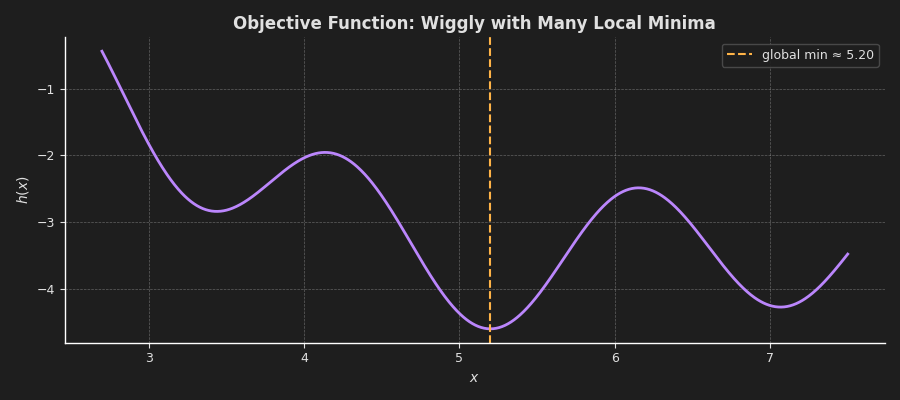

In [3]:
# Wiggly objective: many local minima, one global minimum
def h(x):
    return np.sin(x) + np.sin(10 * x / 3) + np.log(x) - 0.84 * x

# True minimum (from numerical search) near x ≈ 5.2
xs = np.linspace(2.7, 7.5, 1000)
x_star_approx = xs[np.argmin(h(xs))]
print(f"Approximate global minimum: x ≈ {x_star_approx:.4f}, h(x) ≈ {h(x_star_approx):.4f}")

# Plot the objective function
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(xs, h(xs), color=C['purple'], lw=2)
ax.axvline(x_star_approx, color=C['orange'], ls='--', lw=1.5,
           label=f'global min ≈ {x_star_approx:.2f}')
ax.set_xlabel('$x$')
ax.set_ylabel('$h(x)$')
ax.set_title('Objective Function: Wiggly with Many Local Minima')
ax.legend()
plt.tight_layout()

In [4]:
# Run simulated annealing
N = 20_000
rng = np.random.default_rng(2024)

# Cooling schedule: T_n = a / log(n + b), geometric approximation used here
# for speed; classic logarithmic schedule is slow but theoretically optimal
a_cool = 5.0
T_sched = a_cool / np.log(np.arange(2, N + 2))

# Gaussian random-walk proposal on [2.7, 7.5]
lo, hi = 2.7, 7.5
def proposal(theta, rng):
    return np.clip(theta + rng.normal(0, 0.3), lo, hi)

theta0 = rng.uniform(lo, hi)
best, theta_hist, h_hist = simulated_annealing(h, proposal, theta0, T_sched, rng)

print(f"SA result:           x ≈ {best:.4f}, h(x) ≈ {h(best):.4f}")
print(f"True global minimum: x ≈ {x_star_approx:.4f}, h(x) ≈ {h(x_star_approx):.4f}")

SA result:           x ≈ 5.1998, h(x) ≈ -4.6013
True global minimum: x ≈ 5.1985, h(x) ≈ -4.6013


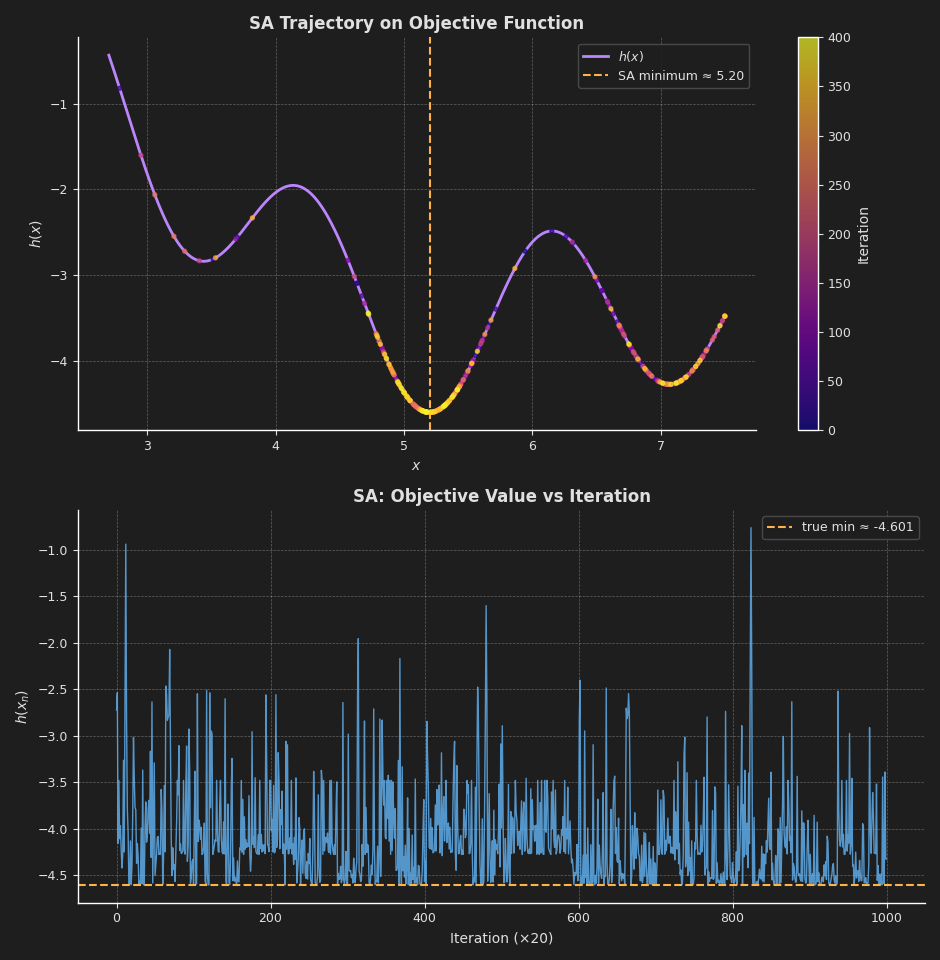

In [5]:
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE_2PANEL)

# Left: objective + SA trajectory (scatter coloured by iteration)
ax = axes[0]
ax.plot(xs, h(xs), color=C['purple'], lw=2, zorder=2, label='$h(x)$')
sc = ax.scatter(theta_hist[::50], h(theta_hist[::50]),
                c=np.arange(len(theta_hist[::50])),
                cmap='plasma', s=8, zorder=3, alpha=0.7)
ax.axvline(best, color=C['orange'], ls='--', lw=1.5, label=f'SA minimum ≈ {best:.2f}')
ax.set_xlabel('$x$')
ax.set_ylabel('$h(x)$')
ax.set_title('SA Trajectory on Objective Function')
ax.legend(fontsize=9)
plt.colorbar(sc, ax=ax, label='Iteration')

# Right: objective value over iterations
ax = axes[1]
ax.plot(h_hist[::20], color=C['blue'], lw=1, alpha=0.8)
ax.axhline(h(x_star_approx), color=C['orange'], ls='--', lw=1.5,
           label=f'true min ≈ {h(x_star_approx):.3f}')
ax.set_xlabel('Iteration (×20)')
ax.set_ylabel('$h(x_n)$')
ax.set_title('SA: Objective Value vs Iteration')
ax.legend()
plt.tight_layout()